<a href="https://colab.research.google.com/github/giamberinigiulia/SPE_Project/blob/plot_notebook/models/plots.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
!git clone https://github.com/giamberinigiulia/SPE_Project.git

Cloning into 'SPE_Project'...
remote: Enumerating objects: 373, done.
remote: Counting objects: 100% (25/25), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 373 (delta 5), reused 21 (delta 4), pack-reused 348 (from 1)
Receiving objects: 100% (373/373), 1.21 MiB | 8.30 MiB/s, done.
Resolving deltas: 100% (160/160), done.
SPE_Project/


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [1]:
def compute_total_response_time(csv_filename: str) -> tuple[float, int]:
    '''Computes the total response time and the number of responses from a CSV file.

    This function reads a CSV file where each row contains response times recorded for a given client in seconds.
    It calculates the total sum of all response times across all rows.

    Parameters:
    -----------
    csv_filename : str
        The path to the CSV file containing response times. Each row represents a set of response times
        separated by commas.

    Returns:
    --------
    tuple[float, int]
        A tuple where:
        - The first element (float) is the total sum of all response times.
        - The second element (int) is the number of responses.
    '''

    total_response_time = 0.0
    number_of_responses = 0

    with open(csv_filename, 'r', newline='') as response_time_csv:
        system_response_times = csv.reader(response_time_csv, delimiter=',')

        for client_response_times in system_response_times:
            for response_time in client_response_times:
                total_response_time += float(response_time)
                number_of_responses += 1

    return total_response_time, number_of_responses

def compute_average_response_time() -> float:
    total_response_time, number_of_responses = compute_total_response_time(".data/csv/response_time.csv")
    return total_response_time/number_of_responses



In [2]:
class DelayAnalyzer:
    def __init__(self, file_path):
        self.file_path = file_path

    def mean_mu_observed(self, mu):
        # Retrieve all the delays observation and eveluate the mean. Also return the number of observed values
        data = pd.read_csv(self.file_path)
        filtered_data = data[data['mu'] == mu]
        n = filtered_data.shape[0]
        if not filtered_data.empty:
            mean_delay = filtered_data['delay'].mean()
            return 1 / mean_delay, n  # Return the rate (1/mean delay)
        else:
            raise ValueError(f"No data found for mu = {mu}")

    def empirical_distribution(self,mu):
        # return all the delays
        data = pd.read_csv(self.file_path)
        filtered_data = data[data['mu'] == mu]
        return filtered_data['delay']


class PlotGenerator:
    def __init__(self, image_path):
        self.file_path = image_path

    def generate_exponential_plot(self, mu, mean_mu, values, n):
        # int(10/mu) + np.log10(mu) in order to have enogh space to represent all data
        # int(10/mu) guarantee that lower values have a correct representation when np.log10(mu) will be 0
        # otherwise if the mu value is higher, np.log10(mu) will be reasonable and int(10/mu) will be zero

        time_values = np.linspace(0, int(10/mu) + np.log10(mu), 1000)
        pdf = mu * np.exp(-mu * time_values)

        plt.figure(figsize=(8, 6))
        plt.hist(values,bins=np.linspace(0, int(10/mu)  + np.log10(mu), 30), density=True)
        plt.plot(time_values, pdf, label=f'PDF (mu = {mu:.2f})')

        plt.xlabel('Time (seconds)')
        plt.ylabel('Probability Density')
        plt.title(f'Exponential Distribution with Rate {mu} vs {mean_mu:.2f} with {n} trials')
        plt.legend()
        plt.grid(True)
        plt.show()
        plt.close()


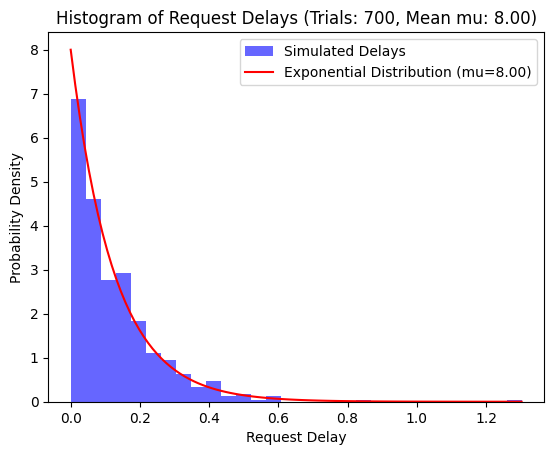

In [7]:
request_delays = "https://raw.githubusercontent.com/giamberinigiulia/SPE_Project/refs/heads/main/data/csv/request_delays_8_0.csv?token=GHSAT0AAAAAACYFQI2QPZ5G4YZ5Z6IXQCIWZZAXWWA"

df_request_delays = pd.read_csv(request_delays)
mu = df_request_delays['mu'][0]
num_trials = len(df_request_delays)
mean_mu = 1/(df_request_delays['delay'].mean())

plt.hist(df_request_delays['delay'], bins=30, density=True, alpha=0.6, color='b', label='Simulated Delays')

x = np.linspace(0, df_request_delays['delay'].max(), 100)
y = mu * np.exp(-mu * x)
plt.plot(x, y, 'r-', label='Exponential Distribution (mu={:.2f})'.format(mu))

plt.xlabel('Request Delay')
plt.ylabel('Probability Density')
plt.title('Histogram of Request Delays (Trials: {}, Mean mu: {:.2f})'.format(num_trials, mean_mu))
plt.legend()
plt.show()